<a href="https://colab.research.google.com/github/karenrosas0410-pixel/Estad-stica-2026B-/blob/main/Proyecto_un3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Introducción

La presente investigación tiene como objetivo analizar el comportamiento de los crímenes registrados en Chihuahua a lo largo del tiempo mediante el uso de herramientas de series de tiempo. Este análisis es importante porque permite observar cómo cambian los delitos durante distintos periodos, identificando aumentos, disminuciones y posibles patrones dentro de los datos.

La utilidad de esta investigación radica en comprender mejor el comportamiento de los crímenes y conocer si existen tendencias o ciclos repetitivos que ayuden a explicar su evolución. Además, este tipo de análisis puede servir como apoyo para futuras investigaciones relacionadas con la seguridad pública y la prevención del delito.

Marco teórico

Las series de tiempo son un conjunto de datos organizados de acuerdo con el tiempo, permitiendo analizar el comportamiento de una variable en diferentes periodos. Este tipo de análisis es utilizado en distintas áreas como economía, finanzas, salud y seguridad, ya que ayuda a identificar patrones y cambios dentro de los datos.

Dentro de las series de tiempo existen diferentes componentes importantes como la tendencia, la estacionalidad y el ruido residual. La tendencia representa el comportamiento general de los datos a largo plazo, mostrando si aumentan o disminuyen con el tiempo. La estacionalidad hace referencia a patrones repetitivos que pueden ocurrir en ciertos periodos, mientras que el ruido residual representa variaciones aleatorias que no siguen un patrón específico.

En esta investigación se utilizaron herramientas como la media móvil y la media exponencial, las cuales permiten suavizar los cambios bruscos para observar mejor el comportamiento general de la serie. También se aplicó una regresión polinomial para analizar la tendencia, el método DFA para estudiar el comportamiento de la serie, las series de Fourier para identificar ciclos repetitivos y la descomposición estacional para separar los componentes principales de la serie temporal.

Metodología

Para la realización de este estudio se trabajó con datos relacionados con los crímenes registrados en Chihuahua durante diferentes periodos de tiempo. El análisis fue realizado en Google Colab utilizando Python y distintas librerías estadísticas que permitieron representar gráficamente y analizar la información.

En primer lugar, se elaboró la gráfica de la serie de tiempo, agregando una media móvil y una media exponencial con el fin de observar de forma más clara el comportamiento general de los crímenes. Posteriormente, se aplicó el método DFA para analizar las características de la serie temporal.

Después, se representó la tendencia mediante una regresión polinomial para identificar el comportamiento general de los delitos a través del tiempo. También se utilizaron series de Fourier para detectar patrones repetitivos o ciclos dentro de la información. Además, se aplicó una descomposición estacional para separar los componentes de tendencia, estacionalidad y ruido residual. Finalmente, se realizó una prueba estadística utilizando el valor p para determinar si la estacionalidad presentaba un efecto significativo.




In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/mexico_crime.csv.zip', compression='zip')
display(df.head())

,year,entity_code,entity,affected_legal_good,type_of_crime,subtype_of_crime,modality,month,count
0,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With firearm,January,3
1,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With sharp weapon,January,1
2,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,With another element,January,0
3,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Intentional Homicide,Not specified,January,2
4,2015,1,Aguascalientes,Life and bodily integrity,Homicide,Manslaughter,With firearm,January,0


In [ ]:
df["entity"].unique()

array(['Aguascalientes', 'Baja California', 'Baja California Sur',
       'Campeche', 'Coahuila de Zaragoza', 'Colima', 'Chiapas',
       'Chihuahua', 'Ciudad de México', 'Durango', 'Guanajuato',
       'Guerrero', 'Hidalgo', 'Jalisco', 'México', 'Michoacán de Ocampo',
       'Morelos', 'Nayarit', 'Nuevo León', 'Oaxaca', 'Puebla',
       'Querétaro', 'Quintana Roo', 'San Luis Potosí', 'Sinaloa',
       'Sonora', 'Tabasco', 'Tamaulipas', 'Tlaxcala',
       'Veracruz de Ignacio de la Llave', 'Yucatán', 'Zacatecas'],
      dtype=object)

In [ ]:
df = df[df["entity"] == "Chihuahua"]

In [ ]:
df["month"] = df["month"].map({ "January" : "01" , "February" : "02" , "March" : "03" , "April" : "04" , "May" : "05" , "June" : "06" , "July" : "07" , "August" : "08" , "September" : "09" , "October" : "10" , "November" : "11" , "December" : "12" })

In [ ]:
df["Date"] = df["year"].astype(str) + "-" + df["month"].astype(str) + "-01"

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

In [ ]:
df.groupby('type_of_crime')["count"].sum()

,count
type_of_crime,
Abduction,0
Abortion,85
Aggravated rape,2200
Burglary,5698
Child trafficking,12
Corruption of minors,973
Counterfeiting,6037
Crimes committed by public officials,7964
Dispossession,6977


In [ ]:
df = df[df["type_of_crime"] == "Homicide"]

In [ ]:
df = (df.groupby("Date")["count"].sum())

In [ ]:
df.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 106 entries, 2015-01-01 to 2023-10-01
Series name: count
Non-Null Count  Dtype
--------------  -----
106 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB


In [ ]:
df.describe()

,count
count,106.000000
mean,170.188679
std,42.652553
min,82.000000
25%,141.250000
50%,169.500000
75%,202.500000
max,269.000000


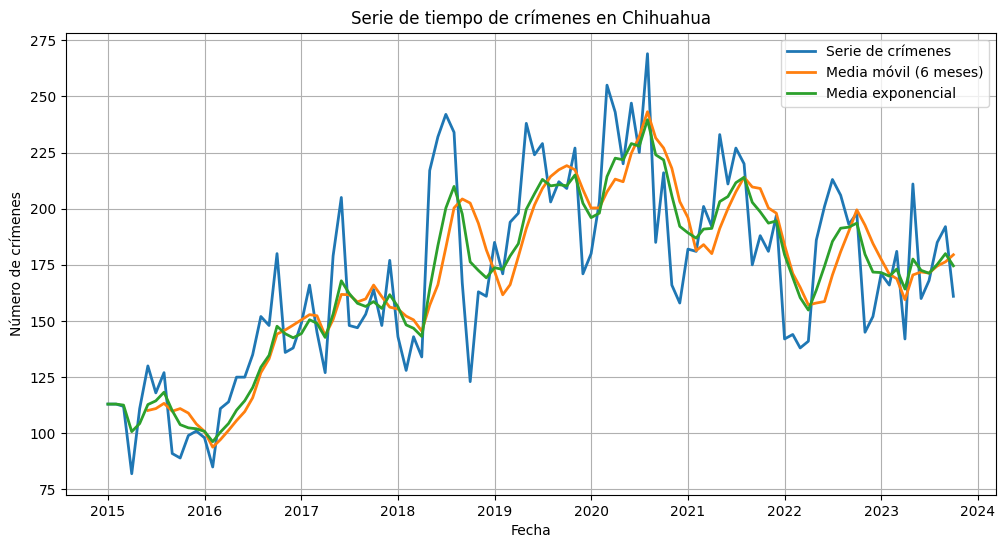

In [38]:
# IMPORTAR LIBRERIAS
import pandas as pd
import matplotlib.pyplot as plt

# The previous cells have already prepared the 'df' variable
# which is now a pandas Series with Date as index and crime counts as values.
# However, based on the error, 'df' appears to be the original DataFrame.
# We will re-process 'df' within this cell to ensure 'serie' is correctly formed.
# Assuming 'df' is the raw DataFrame loaded from CSV at this point

# 1. Filter for Chihuahua
df_processed = df[df["entity"] == "Chihuahua"].copy()

# 2. Filter for Homicide
df_processed = df_processed[df_processed["type_of_crime"] == "Homicide"].copy()

# 3. Convert month names to numbers (re-applying in case of out-of-order execution)
month_mapping = {
    "January": "01", "February": "02", "March": "03", "April": "04", "May": "05", "June": "06",
    "July": "07", "August": "08", "September": "09", "October": "10", "November": "11", "December": "12"
}
# Check if month column is still object type and contains month names before mapping
if df_processed['month'].dtype == 'object' and df_processed['month'].isin(month_mapping.keys()).any():
  df_processed["month"] = df_processed["month"].map(month_mapping)

# 4. Create 'Date' column and convert to datetime
df_processed["Date"] = df_processed["year"].astype(str) + "-" + df_processed["month"].astype(str) + "-01"
df_processed['Date'] = pd.to_datetime(df_processed['Date'], format='%Y-%m-%d')

# 5. Group by 'Date' and sum 'count' to get the final numeric series
serie = df_processed.groupby("Date")["count"].sum()

# MEDIA MOVIL (VENTANA DE 6 MESES)
media_movil = serie.rolling(window=6).mean()

# MEDIA EXPONENCIAL
media_exponencial = serie.ewm(span=6).mean()

# GRAFICA
plt.figure(figsize=(12,6))

plt.plot(serie,
         label='Serie de crímenes',
         linewidth=2)

plt.plot(media_movil,
         label='Media móvil (6 meses)',
         linewidth=2)

plt.plot(media_exponencial,
         label='Media exponencial',
         linewidth=2)

plt.title('Serie de tiempo de crímenes en Chihuahua')
plt.xlabel('Fecha')
plt.ylabel('Número de crímenes')
plt.legend()
plt.grid()
plt.show()

Conforme a la gráfica, se observa que el número de crímenes en Chihuahua cambia constantemente durante el periodo analizado. La serie presenta aumentos y disminuciones, destacando valores más altos entre 2019 y 2021.

La media móvil y la media exponencial permiten ver mejor el comportamiento general, ya que suavizan los cambios bruscos. En general, se aprecia una tendencia de aumento hasta aproximadamente 2020 y después una ligera disminución

In [40]:

# INSTALAR LIBRERIA (solo una vez)
!pip install nolds

# IMPORTAR LIBRERIA
import nolds

# APLICAR DFA
dfa = nolds.dfa(serie.values)

# RESULTADO
print("Valor DFA:", round(dfa,3))

# INTERPRETACION
if dfa < 0.5:
    print("La serie presenta un comportamiento más aleatorio.")
elif dfa >= 0.5 and dfa < 1:
    print("La serie muestra cierta persistencia y posibles patrones.")
else:
    print("La serie parece tener tendencia fuerte o comportamiento persistente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.7/225.7 kB 11.9 MB/s eta 0:00:00
Valor DFA: 1.172
La serie parece tener tendencia fuerte o comportamiento persistente.


Se obtiene un comportamiento fuerte y con tendencia marada

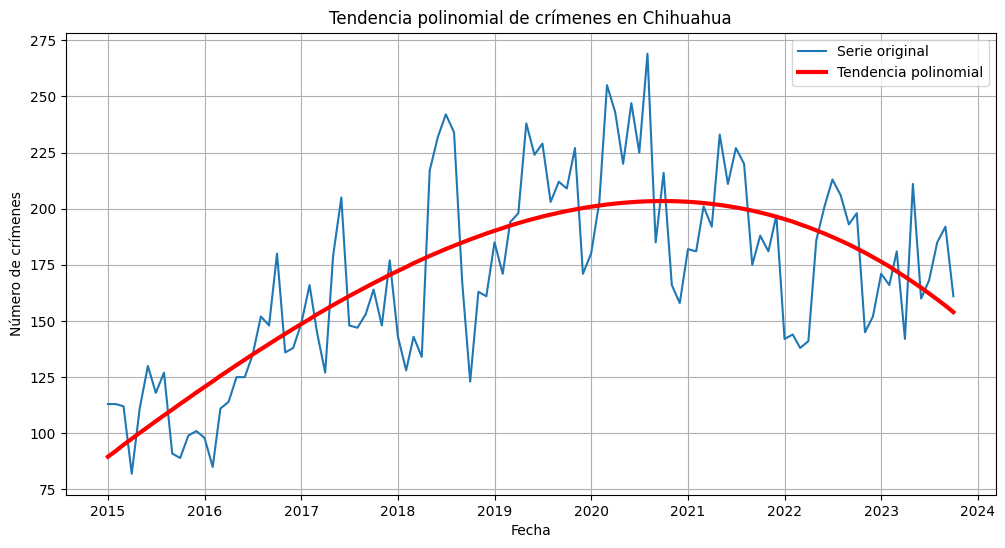

In [42]:

# IMPORTAR LIBRERIAS
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# VARIABLES
x = np.arange(len(serie)).reshape(-1,1)
y = serie.values

# REGRESION POLINOMIAL
poly = PolynomialFeatures(degree=3)
x_poly = poly.fit_transform(x)

modelo = LinearRegression()
modelo.fit(x_poly, y)

# PREDICCION DE LA TENDENCIA
tendencia = modelo.predict(x_poly)

# GRAFICA
plt.figure(figsize=(12,6))

plt.plot(serie.index,
         y,
         label='Serie original')

plt.plot(serie.index,
         tendencia,
         color='red',
         linewidth=3,
         label='Tendencia polinomial')

plt.title('Tendencia polinomial de crímenes en Chihuahua')
plt.xlabel('Fecha')
plt.ylabel('Número de crímenes')
plt.legend()
plt.grid()
plt.show()

Conforme a la gráfica, la tendencia polinomial muestra el comportamiento general de los crímenes en Chihuahua a lo largo del tiempo. Se observa un aumento gradual desde 2015 hasta aproximadamente 2020–2021, donde se alcanzan los valores más altos. Después de ese periodo, la tendencia presenta una disminución moderada, indicando una reducción en el número de crímenes en los años más recientes.

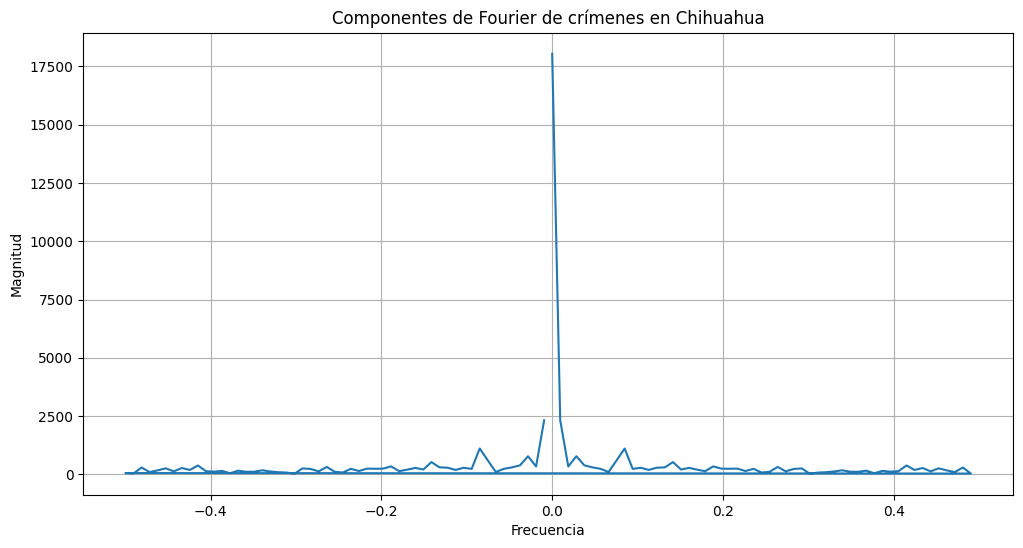

In [43]:

# IMPORTAR LIBRERIA
import numpy as np
import matplotlib.pyplot as plt

# TRANSFORMADA DE FOURIER
fft = np.fft.fft(serie)

# FRECUENCIAS
frecuencia = np.fft.fftfreq(len(serie))

# GRAFICA
plt.figure(figsize=(12,6))

plt.plot(frecuencia,
         np.abs(fft))

plt.title('Componentes de Fourier de crímenes en Chihuahua')
plt.xlabel('Frecuencia')
plt.ylabel('Magnitud')
plt.grid()
plt.show()



Conforme a la gráfica de Fourier, se observa un pico alto importante, lo que indica la presencia de un patrón repetitivo dentro de la serie de crímenes en Chihuahua. Esto puede sugerir que existe cierta estacionalidad o un ciclo que influye en el comportamiento de los delitos a lo largo del tiempo.

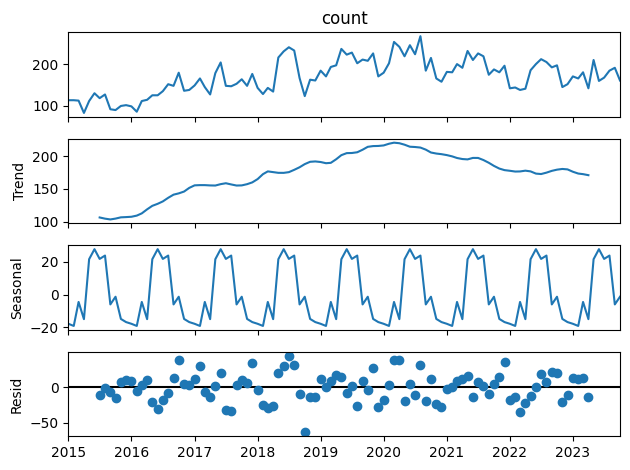

In [44]:

# IMPORTAR LIBRERIA
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# DESCOMPOSICION DE LA SERIE
descomposicion = seasonal_decompose(
    serie,
    model='additive',
    period=12  # mensual
)

# GRAFICAS
descomposicion.plot()
plt.show()


Conforme a la descomposición de la serie, se observa que el número de crímenes en Chihuahua presenta cambios a lo largo del tiempo. La tendencia muestra un aumento gradual desde 2015 hasta aproximadamente 2020, seguido de una disminución moderada en los años posteriores.

En la parte de estacionalidad se observan patrones repetitivos durante el periodo analizado, lo que sugiere que algunos meses presentan comportamientos similares en el número de crímenes. Por otro lado, el ruido residual muestra variaciones irregulares que no siguen un patrón definido, indicando la presencia de cambios aleatorios en la serie.

Conforme a la gráfica de estacionalidad, se observa un patrón repetitivo durante varios periodos, ya que las subidas y bajadas mantienen un comportamiento similar a lo largo del tiempo. Esto sugiere que la estacionalidad sí parece tener un efecto significativo en el número de crímenes en Chihuahua, debido a que ciertos patrones se repiten de forma constante.

In [45]:

# IMPORTAR LIBRERIA
from scipy.stats import f_oneway

# OBTENER EL MES DE CADA DATO
meses = serie.index.month

# AGRUPAR DATOS POR MES
grupos = [
    serie[meses == i]
    for i in range(1,13)
]

# PRUEBA ANOVA
estadistico, p_value = f_oneway(*grupos)

# RESULTADO
print("Valor p =", round(p_value,5))

# INTERPRETACION
if p_value < 0.05:
    print("La estacionalidad SI parece significativa.")
else:
    print("La estacionalidad NO parece significativa.")



Valor p = 0.13192
La estacionalidad NO parece significativa.


Conforme a la prueba estadística realizada, se obtuvo un valor p de 0.13192, el cual es mayor a 0.05. Esto indica que la estacionalidad no parece tener un efecto significativo en el comportamiento de los crímenes en Chihuahua, por lo que los cambios observados no siguen un patrón estacional fuerte.

Resultados

Los resultados obtenidos permitieron observar que los crímenes en Chihuahua presentan variaciones importantes durante el periodo analizado, mostrando aumentos y disminuciones en distintos momentos del tiempo. La serie de tiempo junto con la media móvil y la media exponencial ayudó a visualizar de mejor forma el comportamiento general de los datos, reduciendo el efecto de cambios bruscos.

La regresión polinomial permitió identificar una tendencia general donde los crímenes aumentaron gradualmente hasta aproximadamente el año 2020, presentando posteriormente una disminución moderada. Asimismo, el análisis de Fourier mostró la presencia de un pico importante, lo que indica la existencia de ciertos patrones repetitivos dentro de la serie temporal.

Por otra parte, la descomposición estacional permitió observar comportamientos repetitivos en algunos periodos, sugiriendo cierta presencia de estacionalidad mediante la observación gráfica. Sin embargo, al aplicar la prueba estadística se obtuvo un valor p de 0.13192, el cual es mayor a 0.05, indicando que la estacionalidad no presenta un efecto significativo en el comportamiento de los crímenes registrados en Chihuahua.

Conclusion

Con base en el análisis realizado, se concluye que los crímenes en Chihuahua presentan cambios importantes a lo largo del tiempo, reflejando periodos de aumento y disminución durante el periodo estudiado. Las herramientas de series de tiempo utilizadas permitieron comprender mejor el comportamiento de los datos y visualizar de forma más clara la tendencia general.

Aunque mediante los gráficos se observaron ciertos patrones repetitivos y posibles señales de estacionalidad, la prueba estadística indicó que esta no tiene un efecto significativo sobre el comportamiento de los crímenes. La utilidad de estos hallazgos consiste en ofrecer una mejor comprensión de cómo evolucionan los delitos a través del tiempo, lo cual puede ser de apoyo para futuras investigaciones y análisis relacionados con la seguridad pública.